# APR + Phasor Workflow


### This Notebook's Operations

This workflow starts from `FILENAME_INPUT`, creates a calibrated source file, then appends APR and phasor results into the same output file.

1. `FILENAME_INPUT` -> calibration -> `FILENAME_OUTPUT`
2. `FILENAME_OUTPUT` -> `apr` with `mode="append"` -> `FILENAME_OUTPUT`
3. `FILENAME_OUTPUT` -> `phasor` with `mode="append"` -> same `FILENAME_OUTPUT`

The exported file therefore contains the APR decay output and the phasor lifetime products together under `/output`.

Runs the full phasor calibration and lifetime analysis pipeline on raw BrightEyes MCS `.h5` data.
An optional **Adaptive Pixel Reassignment (APR)** step can be enabled via the `DO_APR` flag
in the parameters cell: the reassigned data overwrites `data_input` in memory before phasor
computation, so no intermediate file is written to disk.

### Workflow overview

1. **Calibration** — Correct per-channel timing offsets (channel skew) and instrument response
   using a reference dye of known lifetime.
2. **Load calibrated data** — Read the photon-count array and auxiliary traces (IRF, reference)
   from the HDF5 file.
3. **Photon flux check** *(optional)* — Verify the per-channel count rates.
4. **APR** *(optional)* — Apply Adaptive Pixel Reassignment to co-register all SPAD channels
   before analysis.
5. **Phasor computation** — Compute per-pixel phasors from the shift-corrected, channel-summed
   decay traces.
6. **Phasor correction** — Remove the instrument response (IRF or reference-dye calibration)
   from the phasors.
7. **Lifetime maps** — Derive τ_m and τ_φ maps and produce summary figures.


In [1]:
# ── File paths ────────────────────────────────────────────────────────────
FILE_REFERENCE = '/mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5'
FILENAME_INPUT = '/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5'

DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')

# ── Calibration parameters ─────────────────────────────────────────────────

TAU_REF              = None
REFERENCE_TYPE       = "ref"
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True

# ── APR parameters ─────────────────────────────────────────────────────────

# Set to True to apply pixel reassignment before phasor computation
DO_APR = True

# Spatial crop applied to image[0, 0, ...] as (row_start, row_end, col_start, col_end)
# Set to None to keep the full field of view
ROI = None #(1000, 1750, 1200, 1950)

# Index of the central detector element used as the reassignment reference
REF_CHANNEL = 12

# Sub-pixel up-sampling factor for shift-vector (higher = more accurate but slower)
USF = 100

# Pixel-reassignment interpolation mode: 'interp' (bilinear) or 'fft'
REASSIGN_MODE = "interp"



FILENAME_OUTPUT = FILENAME_INPUT.replace(".h5", "_phasor_workflow.h5")

print(f"Input file (ref): {FILE_REFERENCE}")
print(f"Input file (data): {FILENAME_INPUT}")
print(f"Calibration and output products to: {FILENAME_OUTPUT}")


Input file (ref): /mnt/DATA/Mixed Data/Giuse2/RefFarRed_DFD.h5
Input file (data): /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD.h5
Calibration and output products to: /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_phasor_workflow.h5


## Imports

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# APR
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gr

# Phasor Workflow
import brighteyes_flism.tools_phasor as flim
import brighteyes_flism.graph_tools as graph
from brighteyes_mcs_file import Alignment, H5OutputProduct, calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts, write_h5_output_run



In [3]:
# Derived HDF5 schema keys. Do not edit unless the schema changes.
DATA_KEY_TO_CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]
CALIBRATION_PRODUCT = DATA_KEY_TO_CALIBRATION_PRODUCT[INSPECT_DATA_KEY]


## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing
the aligned per-channel IRF and reference traces, the per-channel timing offsets (channel skew),
and the laser timing parameters.
If `OVERWRITE = True` the calibration is recomputed even if a calibrated file already exists.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing
> reference. `channel_skew_fit_upsampling=10` enables sub-bin precision in the cross-correlation.


In [4]:
calibrate_h5_file(
    FILENAME_INPUT,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    output_path=FILENAME_OUTPUT,
    overwrite=OVERWRITE,
)



Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

'/mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_phasor_workflow.h5'

## Load Calibrated Data

All arrays and metadata are read from the calibrated HDF5 file.

| Variable | Shape | Description |
|---|---|---|
| `data_input` | `(rep, z, y, x, t_bins, channels)` | Raw photon counts |
| `channel_skew` | `(channels,)` | Per-channel timing offset [bins] |
| `irf_common_delay_realigned` | `(t_bins, channels)` | Aligned IRF traces |
| `ref_common_delay_realigned` | `(t_bins, channels)` | Aligned reference-dye traces |
| `laser_freq_mhz` | scalar | Laser repetition frequency [MHz] |
| `laser_period_ns` | scalar | Laser period [ns] |
| `nbin` | scalar | Number of TCSPC time bins per period |
| `pixel_size_x_um` | scalar | Lateral pixel size [µm] |
| `pxdwelltime` | scalar | Pixel dwell time [µs] |


In [5]:
with h5py.File(FILENAME_OUTPUT, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                  = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew                = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned  = calibration["aligned/irf_trace"][:]
    ref_common_delay_realigned  = calibration["aligned/reference_trace"][:]
    tau_reference_ns = calibration["fit/tau_reference_ns"][:] if "fit" in calibration and "tau_reference_ns" in calibration["fit"] else np.asarray([], dtype=float)

# Time axis in ns (used for fitting)
t = np.arange(nbin, dtype=float) * laser_period_ns / nbin

tau_reference_ns = tau_reference_ns[np.isfinite(tau_reference_ns)]
if TAU_REF is None:
    if REFERENCE_TYPE == "ref":
        if tau_reference_ns.size == 0:
            raise ValueError(
                f"TAU_REF is None and /calibration/results/{CALIBRATION_PRODUCT}/fit/tau_reference_ns "
                "is missing or non-finite."
            )
        tau_ref_for_phasor_ns = float(np.median(tau_reference_ns))
    else:
        tau_ref_for_phasor_ns = np.nan
else:
    tau_ref_for_phasor_ns = float(TAU_REF)
if np.isfinite(tau_ref_for_phasor_ns):
    print(f"Reference lifetime for phasor correction: {tau_ref_for_phasor_ns:.4f} ns")
else:
    print("Reference lifetime is not used for IRF phasor correction.")


print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print(f"data_input shape: {data_input.shape}  (rep, z, y, x, t_bins, channels)")




Reference lifetime for phasor correction: 5.4908 ns
Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input shape: (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


## Photon Flux Per SPAD Channel

Compute the total photon count and the average count rate (flux) for each SPAD channel.

In [6]:
# Total photon counts per SPAD channel, summed over rep, z, x, y, and time bins
n_foton_per_channel = np.sum(data_input, axis=(0, 1, 2, 3, 4))
n_rep, n_frame, nx, ny = data_input.shape[0], data_input.shape[1], data_input.shape[2], data_input.shape[3]
n_px_total = n_rep * n_frame * nx * ny

# Count rate [Hz] = total photons per channel / total acquisition time
total_time_s = n_px_total * pxdwelltime * 1e-6
flux_per_channel = n_foton_per_channel / total_time_s  # shape: (25,)

# Mean flux across all channels (in kHz)
flux_total = flux_per_channel.sum()

print(f"Pixel dwell time:     {pxdwelltime:.3f} µs")
print(f"Total time of acquisition:  {total_time_s:.4f} s")
print(f"Mean flux total:  {flux_total * 1e-3:.2f} kHz")
print(f"Mean flux per channel (kHz):")
for i, val in enumerate(flux_per_channel, 1):
    print(f"{val *1e-3:<8.2f}", end="" if i % 5 != 0 else "\n")



Pixel dwell time:     182.000 µs
Total time of acquisition:  47.7102 s
Mean flux total:  2664.60 kHz
Mean flux per channel (kHz):
68.30   85.93   94.59   88.11   71.06   
90.55   122.57  138.08  122.35  95.79   
105.57  147.73  165.14  141.55  100.24  
98.18   133.07  145.55  124.73  90.82   
76.62   95.25   102.10  89.77   70.95   


## APR — Pixel Reassignment *(optional)*

Controlled by `DO_APR` in the parameters cell.
When enabled, the shift vectors are estimated from the intensity image (sum over time bins)
and the reassignment is then applied **independently to each time bin**, fully preserving the
TCSPC decay information required for phasor analysis.

`data_input` is overwritten in memory with the spatially-reassigned array;
all downstream cells are unaffected.

Shift vectors are printed in **nanometres** for physical interpretability
(pixel size is read from the metadata).


Shift vectors (dy, dx) per channel:
[[-185.518591    -98.63013699]
 [-164.38356164  -14.09001957]
 [-141.68297456   67.31898239]
 [-104.89236791  150.29354207]
 [ -75.14677104  231.70254403]
 [-129.94129159 -133.07240705]
 [ -93.9334638   -52.44618395]
 [ -67.31898239   32.87671233]
 [ -39.13894325  116.63405088]
 [ -11.74168297  194.91193738]
 [ -54.01174168 -163.60078278]
 [ -25.04892368  -82.97455969]
 [   0.            0.        ]
 [  25.04892368   84.54011742]
 [  47.74951076  165.94911937]
 [  14.09001957 -194.91193738]
 [  36.00782779 -113.50293542]
 [  61.83953033  -31.3111546 ]
 [  90.80234834   51.66340509]
 [ 116.63405088  136.98630137]
 [  72.79843444 -215.26418787]
 [ 103.32681018 -140.90019569]
 [ 132.28962818  -64.18786693]
 [ 161.25244618   25.83170254]
 [ 179.25636008  109.5890411 ]]


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


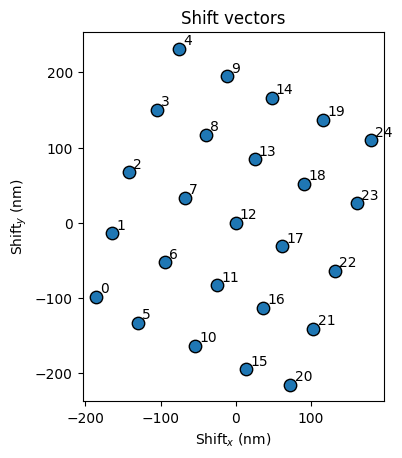

Reassigning time bins: 100%|██████████| 91/91 [01:20<00:00,  1.14it/s]

APR complete — data_input shape: (1, 1, 512, 512, 91, 25)


In [7]:
if DO_APR:

    # Select the first rep and z-plane -> (y, x, t_bins, channels)
    image_4D = data_input[0, 0, ...]

    # Apply the spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]
        print(f"ROI applied — cropped shape: {image_4D.shape}")

    # Collapse time bins to get the intensity image (y, x, channels),
    # used only for shift-vector estimation (time-independent operation)
    image_intensity = np.sum(image_4D, axis=-2)

    # Estimate sub-pixel shift vectors between each channel and the reference detector 
    # Returns: shift_vectors (n_channels, 2) — one (dy, dx) pair per channel [pixels]
    shift_vectors, estimation_error = apr.ShiftVectors(
        image_intensity, usf=USF, ref=REF_CHANNEL
    )

    # Convert shift vectors to nanometres for display
    pixel_size_nm = pixel_size_x_um * 1000
    shift_vectors_nm = shift_vectors * pixel_size_nm

    print("Shift vectors (dy, dx) per channel:")
    print(shift_vectors_nm)
    
    # Visualise the shift vectors on a grid matching the SPAD array geometry
    gr.PlotShiftVectors(shift_vectors_nm)
    plt.show()

    # Apply reassignment independently for each time bin and overwrite data_input
    n_x, n_y, n_bins, n_ch = image_4D.shape
    reassigned = np.empty_like(image_4D, dtype=np.float32)

    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned[:, :, b, :] = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )

    # Wrap back to (1, 1, x, y, t_bins, channels) to match the original shape
    data_input = reassigned[np.newaxis, np.newaxis, ...]   # overwrite in memory
    print(f"APR complete — data_input shape: {data_input.shape}")

else:
    print("APR skipped (DO_APR = False)")





In [8]:
if DO_APR:
    if FILENAME_OUTPUT is not None:
        apr_common_attrs = {
            "source_data_path": f"/raw/{CALIBRATION_PRODUCT}",
            "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
            "source_metadata_path": "/raw/metadata",
            "source_axes_path": "/raw/axes",
            "time_axis_source": "/raw/axes/digital_time_ns",
            "time_bin_ns": laser_period_ns / nbin,
            "laser_frequency_mhz": laser_freq_mhz,
            "laser_period_ns": laser_period_ns,
        }
        apr_summed = data_input.sum(axis=-1)
        target_path, output_run_id = write_h5_output_run(
            FILENAME_OUTPUT,
            "apr",
            [
                H5OutputProduct(
                    "spad",
                    data_input,
                    attrs={
                        **apr_common_attrs,
                        "data_role": "apr_reassigned_spad_detector_counts",
                        "axis_order": "repetition,z,y,x,time_bin,detector_channel",
                    },
                ),
                H5OutputProduct(
                    "apr",
                    apr_summed,
                    attrs={
                        **apr_common_attrs,
                        "data_role": "apr_reassigned_channel_summed_decay",
                        "axis_order": "repetition,z,y,x,time_bin",
                        "source_data_path": "/output/{run_id}/products/spad",
                    },
                )
            ],
            mode="append",
            output_path=None,
            output_key_overwrite=True,
            output_type="image_tool",
            tool_name="APR Reassignment",
            algorithm_name="adaptive_pixel_reassignment",
            parameters={
                "ref_channel": REF_CHANNEL,
                "usf": USF,
                "reassign_mode": REASSIGN_MODE,
                "roi_json": [] if ROI is None else list(ROI),
                "data_key": DATA_KEY,
                "calibration_product": CALIBRATION_PRODUCT,
            },
            metadata={
                **apr_common_attrs,
                "pixel_size_x_um": pixel_size_x_um,
                "pixel_dwell_time_us": pxdwelltime,
                "output_nrep": data_input.shape[0],
                "output_nz": data_input.shape[1],
                "output_ny": data_input.shape[2],
                "output_nx": data_input.shape[3],
                "output_time_bins": data_input.shape[-2],
                "apr_summed_path": "/output/{run_id}/products/apr",
                "selected_channel_count": data_input.shape[-1],
                "shift_vectors_path": "/output/{run_id}/intermediates/shift_vectors",
            },
            axes=[
                H5OutputProduct("repetition_index", np.asarray([0.0]) if data_input.shape[0] == 1 else np.arange(data_input.shape[0], dtype=float), attrs={"axis": "repetition", "long_name": "repetition index", "units": "index"}),
                H5OutputProduct("time_ns", t, attrs={"axis": "time_bin", "long_name": "time", "units": "ns"}),
                H5OutputProduct("x_um", np.linspace(-pixel_size_x_um * (data_input.shape[3] - 1) / 2, pixel_size_x_um * (data_input.shape[3] - 1) / 2, data_input.shape[3]) if data_input.shape[3] > 1 else np.asarray([0.0]), attrs={"axis": "x", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "x position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((data_input.shape[3] - 1) * pixel_size_x_um) if data_input.shape[3] > 1 else 0.0, "units": "um"}),
                H5OutputProduct("y_um", np.linspace(-pixel_size_x_um * (data_input.shape[2] - 1) / 2, pixel_size_x_um * (data_input.shape[2] - 1) / 2, data_input.shape[2]) if data_input.shape[2] > 1 else np.asarray([0.0]), attrs={"axis": "y", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "y position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((data_input.shape[2] - 1) * pixel_size_x_um) if data_input.shape[2] > 1 else 0.0, "units": "um"}),
                H5OutputProduct("z_um", np.asarray([0.0]) if data_input.shape[1] == 1 else np.arange(data_input.shape[1], dtype=float), attrs={"axis": "z", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "z position", "offset_um": 0.0, "pixel_size_um": 0.0, "range_um": 0.0, "units": "um"}),
            ],
            attrs={
                **apr_common_attrs,
                "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
                "output_axis_order": "repetition,z,y,x,time_bin",
                "output_data_path": "/output/{run_id}/products/apr",
                "all_channel_output_data_path": "/output/{run_id}/products/spad",
                "shift_vectors_path": "/output/{run_id}/intermediates/shift_vectors",
            },
            set_default=True,
            intermediates=[
                H5OutputProduct(
                    "shift_vectors",
                    shift_vectors,
                    attrs={
                        "axes": "detector_channel,shift_component",
                        "shift_components_json": ["dy", "dx"],
                        "units": "pixels",
                    },
                )
            ],
        )
        PIPELINE_H5 = target_path
        APR_OUTPUT_RUN_ID = output_run_id
        APR_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/spad"
        APR_SUMMED_OUTPUT_DATA_PATH = f"/output/{output_run_id}/products/apr"
        print(f"Saved {output_run_id} -> {target_path}")
    else:
        PIPELINE_H5 = FILENAME_OUTPUT
        APR_OUTPUT_RUN_ID = ""
        APR_OUTPUT_DATA_PATH = f"/raw/{CALIBRATION_PRODUCT}"
        APR_SUMMED_OUTPUT_DATA_PATH = ""
        print("Export skipped (FILENAME_OUTPUT = None).")
else:
    PIPELINE_H5 = FILENAME_OUTPUT
    APR_OUTPUT_RUN_ID = ""
    APR_OUTPUT_DATA_PATH = f"/raw/{CALIBRATION_PRODUCT}"
    APR_SUMMED_OUTPUT_DATA_PATH = ""
    print("APR skipped (DO_APR = False)")


Saved apr -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_phasor_workflow.h5


## APR — Before / After Intensity Comparison

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.
Both images are displayed with a physical scale bar and a calibrated colour scale
(counts per pixel dwell time).

**What to expect:**
- The APR image should appear sharper than the raw (finer features better resolved).
- The total intensity should be conserved; a small loss at the borders is normal
  (photons shifted outside the field of view are discarded by the interpolation).


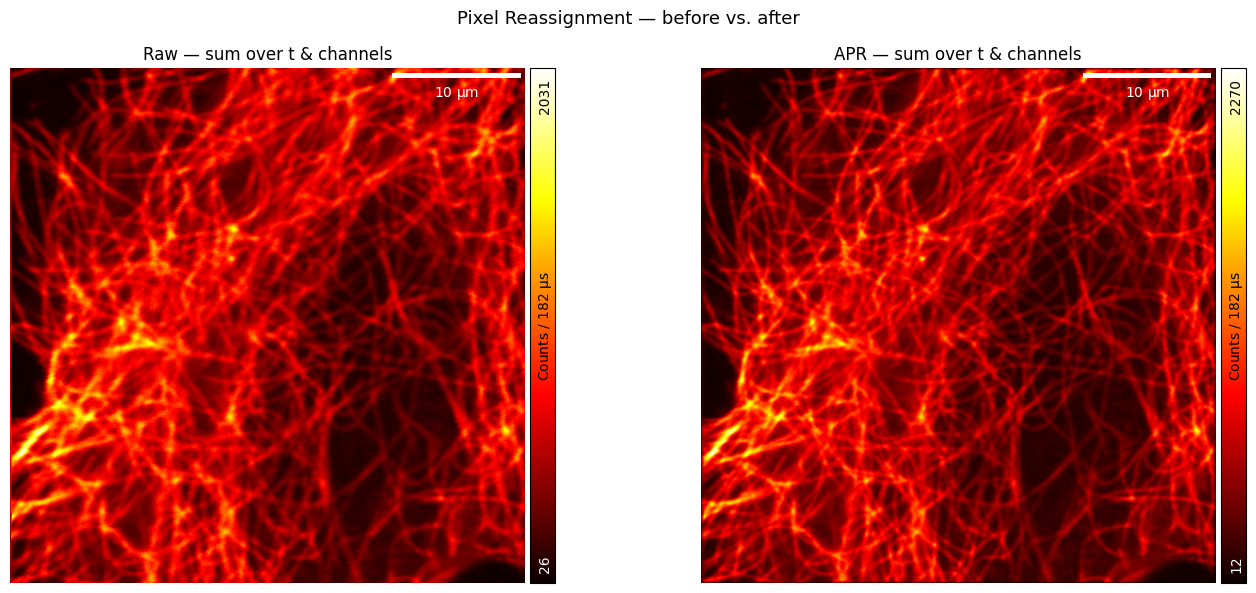

Raw image — min: 26  max: 2031
APR image — min: 12.0  max: 2270.0
Total counts — Raw: 127128805  APR: 128691120
Intensity conservation: 101.23% of raw counts retained


In [9]:
if DO_APR:
    # Sum over t_bins (axis -2) and channels (axis -1) → 2-D intensity map (y, x)
    intensity_raw = np.sum(image_4D,   axis=(-2, -1))
    intensity_apr = np.sum(reassigned, axis=(-2, -1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Use ShowImg to display images with a physical scale bar and calibrated colour scale,
    # matching the format used throughout the rest of the pipeline.
    gr.ShowImg(intensity_raw, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[0])
    axes[0].set_title("Raw — sum over t & channels")

    gr.ShowImg(intensity_apr, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[1])
    axes[1].set_title("APR — sum over t & channels")

    fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
    print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")
    print(f"Total counts — Raw: {intensity_raw.sum():.0f}  APR: {intensity_apr.sum():.0f}")
    print(f"Intensity conservation: {100 * intensity_apr.sum() / intensity_raw.sum():.2f}% of raw counts retained")

else:
    print("DO_APR = False — skipping before/after comparison.")

## Compute Phasors

Before computing phasors, the per-channel TCSPC traces are summed across all 25 SPAD channels
with the timing-skew correction applied along the time axis (`sum_channel_applying_shifts`).
This yields a single spatially-resolved decay trace per pixel.

Three variants are computed for diagnostic purposes:
- **no alignment** — raw sum with no skew correction (reference only).
- **aligned** (default) — shift-corrected sum; used for all downstream analysis.
- **reversed** — sum with shifts applied in the opposite direction; used by
  `plot_channel_skew_correction` to verify that the calibration direction is correct.

> **Optional IRF cleaning** (`if False` block): `Alignment.clean_irf_stack` can suppress
> noisy tails in the IRF by zeroing bins outside a window around the peak. Enable it by
> changing `if False` to `if True` if your IRF shows significant baseline noise or ringing.
> Use this only when `REFERENCE_TYPE = 'ref'`; with `REFERENCE_TYPE = 'irf'` the IRF
> cleaning should be omitted or applied with care.


In [10]:
# Optional: suppress baseline noise / ringing in the IRF traces.
# Enable by changing `if False` to `if True`.
# Recommended only when REFERENCE_TYPE = 'ref'.
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

# Shift-corrected channel sums
data_summed     = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed      = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
ref_summed      = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=())

# Reversed shifts
data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0, ...]
irf_summed_rev  = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)
ref_summed_rev  = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)

# Compute per-pixel phasors at the fundamental harmonic
h5_dataset_phasor_pix = flim.calculate_phasor(data_summed, harmonic=1)
irf_phasor            = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)
ref_phasor            = flim.calculate_phasor(ref_summed, threshold=0, harmonic=1)

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("ref_summed:", ref_summed.shape)
print("phasor map:", h5_dataset_phasor_pix.shape)



Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/18 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Summing shifted histogram chunks:   0%|          | 0/1 [00:00<?, ?it/s]

data_summed: (512, 512, 91)
irf_summed: (91,)
ref_summed: (91,)
phasor map: (512, 512)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

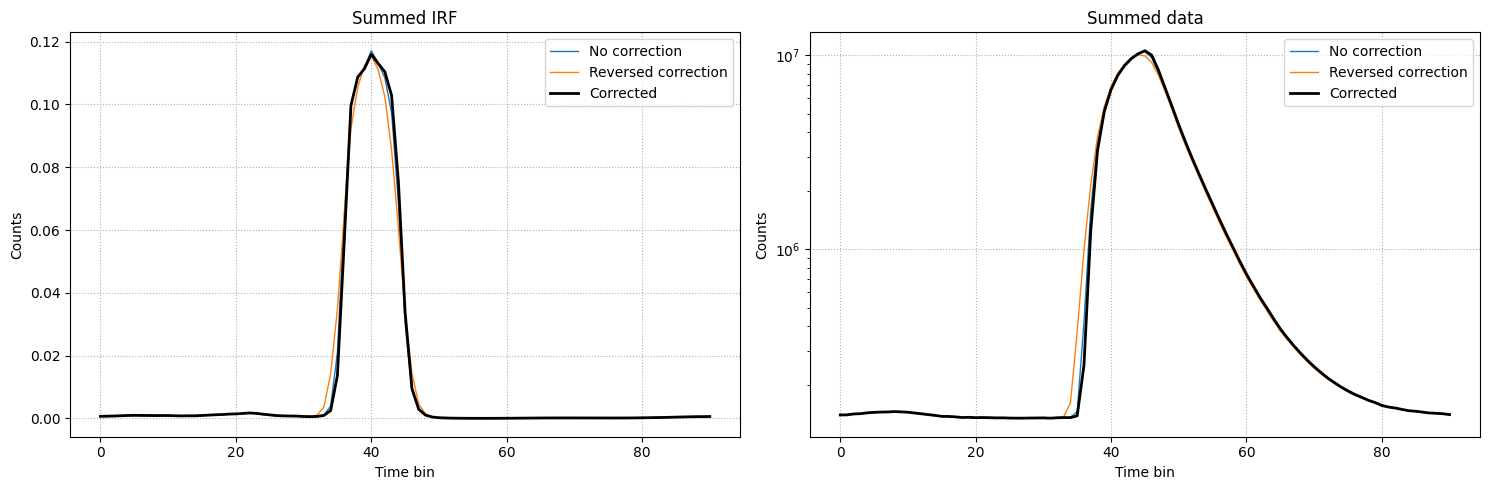

In [11]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)



## Correct Phasors and Build Lifetime Maps

The raw phasors carry the phase and modulation distortion introduced by the instrument
(IRF, electronics, optical path). The correction strategy depends on `REFERENCE_TYPE`:

| `REFERENCE_TYPE` | Correction | Formula |
|---|---|---|
| `'ref'` | Divide by system response estimated from the reference dye | `phasor / (ref_measured / ref_theoretical)` |
| `'irf'` | Divide directly by the IRF phasor | `phasor / irf_phasor` |

After correction, two lifetime estimators are derived per pixel:
- **τ_m** (modulation lifetime): `τ_m = √(1/|p|² − 1) / ω` — sensitive to the width of the lifetime distribution.
- **τ_φ** (phase lifetime): `τ_φ = tan(φ) / ω` — sensitive to the mean lifetime.

For a pure mono-exponential emitter, τ_m = τ_φ. A difference between the two indicates
multi-exponential decay or FRET.


In [12]:
intensity_map = data_summed.sum(axis=-1)

if REFERENCE_TYPE == 'ref':
    if ref_phasor is None:
        raise ValueError("REFERENCE_TYPE='ref' requires /aligned/reference_trace in the calibration results.")
    # Theoretical phasor of the monoexponential reference sample
    omega = 2 * np.pi * laser_freq_mhz * 1e6          # rad/s
    tau_ref_s = tau_ref_for_phasor_ns * 1e-9                          # ns → s
    ref_phasor_theoretical = 1.0 / (1.0 - 1j * omega * tau_ref_s)

    # The system response = measured_ref / theoretical_ref
    correction = ref_phasor / ref_phasor_theoretical

    print(f"Ref phasor measured:  {ref_phasor:.6f}")
    print(f"Ref phasor theoretical:   {ref_phasor_theoretical:.6f}")
    print(f"Correction factor:    {correction:.6f}")

else:  # REFERENCE_TYPE == 'irf'
    correction = irf_phasor

    #if  'complex' == "phase_only":
    #    irf_correction = irf_phasor / abs(irf_phasor)
    #else:
    #    irf_correction = irf_phasor


phasor_map   = h5_dataset_phasor_pix / correction
tau_m_map    = flim.calculate_tau_m(phasor_map,   dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map  = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map    # choose tau_m as the primary lifetime estimator

threshold = 0.05    # pixels below (threshold × max intensity) are excluded
thresholded_phasor_map    = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map, intensity=intensity_map, threshold=threshold,
)

print("IRF phasor:", irf_phasor)
print("thresholded pixels:", thresholded_tau_map.size)



Ref phasor measured:  -0.444113-0.300768j
Ref phasor theoretical:   0.344308+0.475142j
Correction factor:    -0.859169+0.312104j
IRF phasor: (-0.8664612873709885+0.35314336980616107j)
thresholded pixels: 251695


/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


Text(0.5, 1.0, 'Corrected phasor distribution')

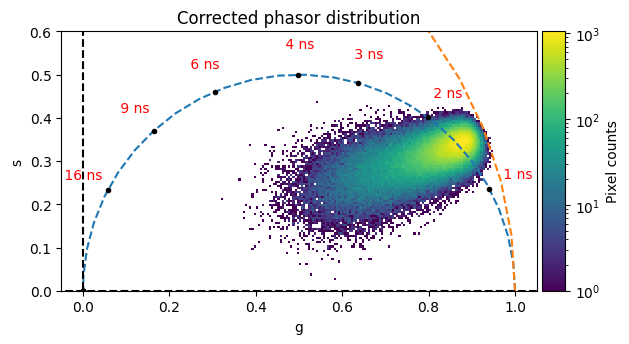

In [13]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title("Corrected phasor distribution")



## τ_m / τ_φ Comparison

Comparing the two lifetime estimators gives insight into the complexity of the fluorescence decay:

- **Histograms** (left) — overlapping distributions of τ_m and τ_φ across all valid pixels.
- **Scatter plot** (centre) — τ_φ vs τ_m per pixel; points on the diagonal indicate mono-exponential behaviour.
- **Difference histogram** (right) — distribution of (τ_φ − τ_m); a peak at 0 indicates
  mono-exponential decay; a non-zero peak or broad distribution indicates multi-exponential decay or FRET.


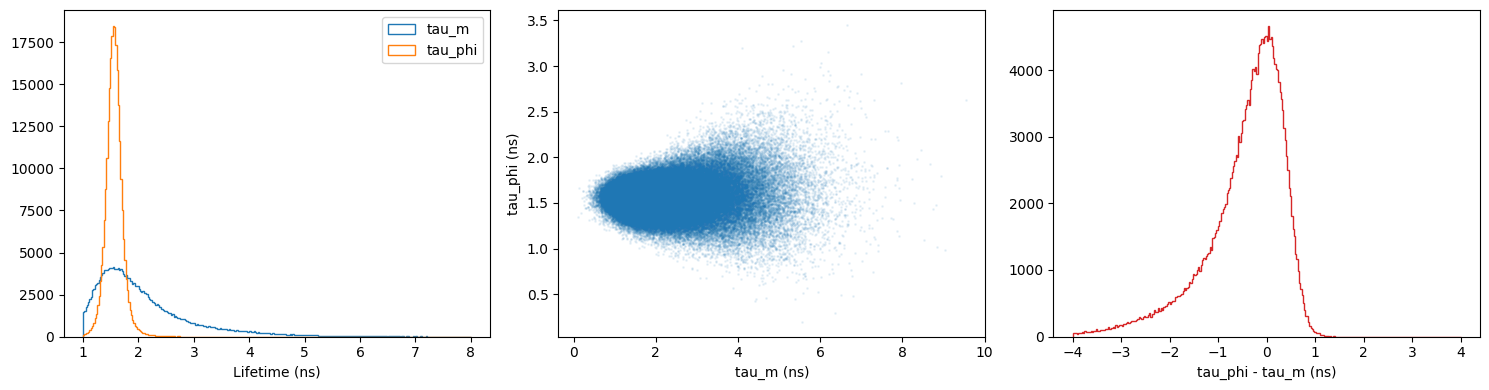

In [14]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare   = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(tau_m_compare,   bins=300, range=(1, 8), histtype="step", label="tau_m")
axs[0].hist(tau_phi_compare, bins=300, range=(1, 8), histtype="step", label="tau_phi")
axs[0].set_xlabel("Lifetime (ns)")
axs[0].legend()
axs[1].scatter(tau_m_compare, tau_phi_compare, s=1, alpha=0.08)
axs[1].set_xlabel("tau_m (ns)")
axs[1].set_ylabel("tau_phi (ns)")
axs[2].hist(tau_diff_compare, bins=300, range=(-4, 4), histtype="step", color="tab:red")
axs[2].set_xlabel("tau_phi - tau_m (ns)")
fig.tight_layout()



## Lifetime Visualisation

`plot_lifetime_summary` produces a multi-panel overview combining the intensity image,
the lifetime map (colour-coded by τ_m), and a weighted histogram of lifetime values.

`plot_equalized_lifetime_summary` applies a histogram-equalised colour mapping to the lifetime,
which improves contrast in samples where the lifetime distribution is narrow.

**Parameters to adjust:**
- `lifetime_bounds` — Colour scale limits for the lifetime map [ns].
- `crop` — Pixels to trim from each border (removes reconstruction edge artefacts).
- `colormap` — Any matplotlib colourmap (`"turbo"`, `"jet"`, `"magma"`, etc.).
- `weighted_histogram` — If `True`, each pixel is weighted by its intensity in the histogram.
- `equalization_strength` — Controls how aggressively the colour scale is equalised (higher = more contrast).


/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)
/home/mdonato/myDev/FLIM/BrightEyes-ISM/src/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

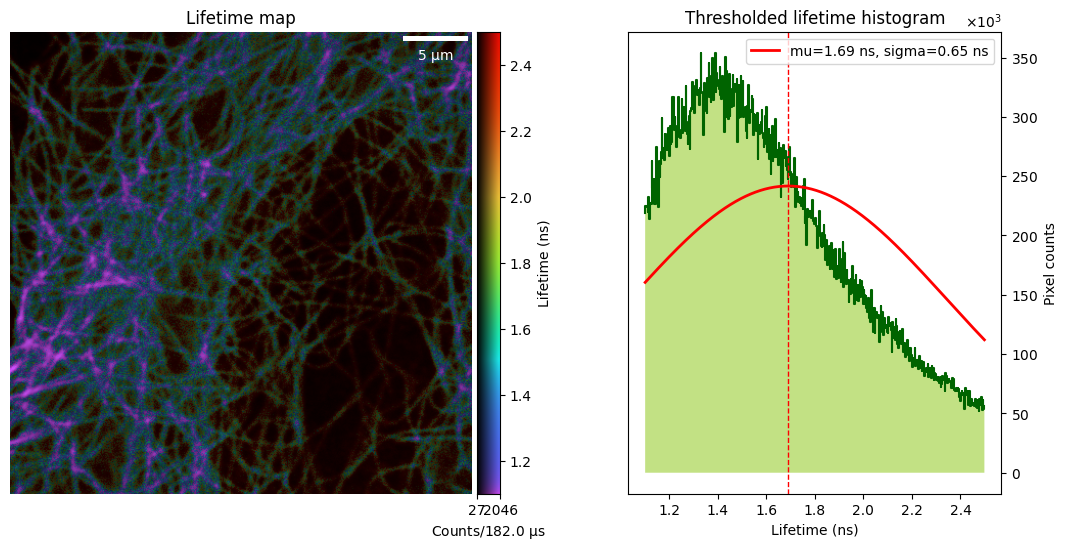

In [15]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.1, 2.5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)



/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/FLIM/BrightEyes-Flim/src/brighteyes_flism/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

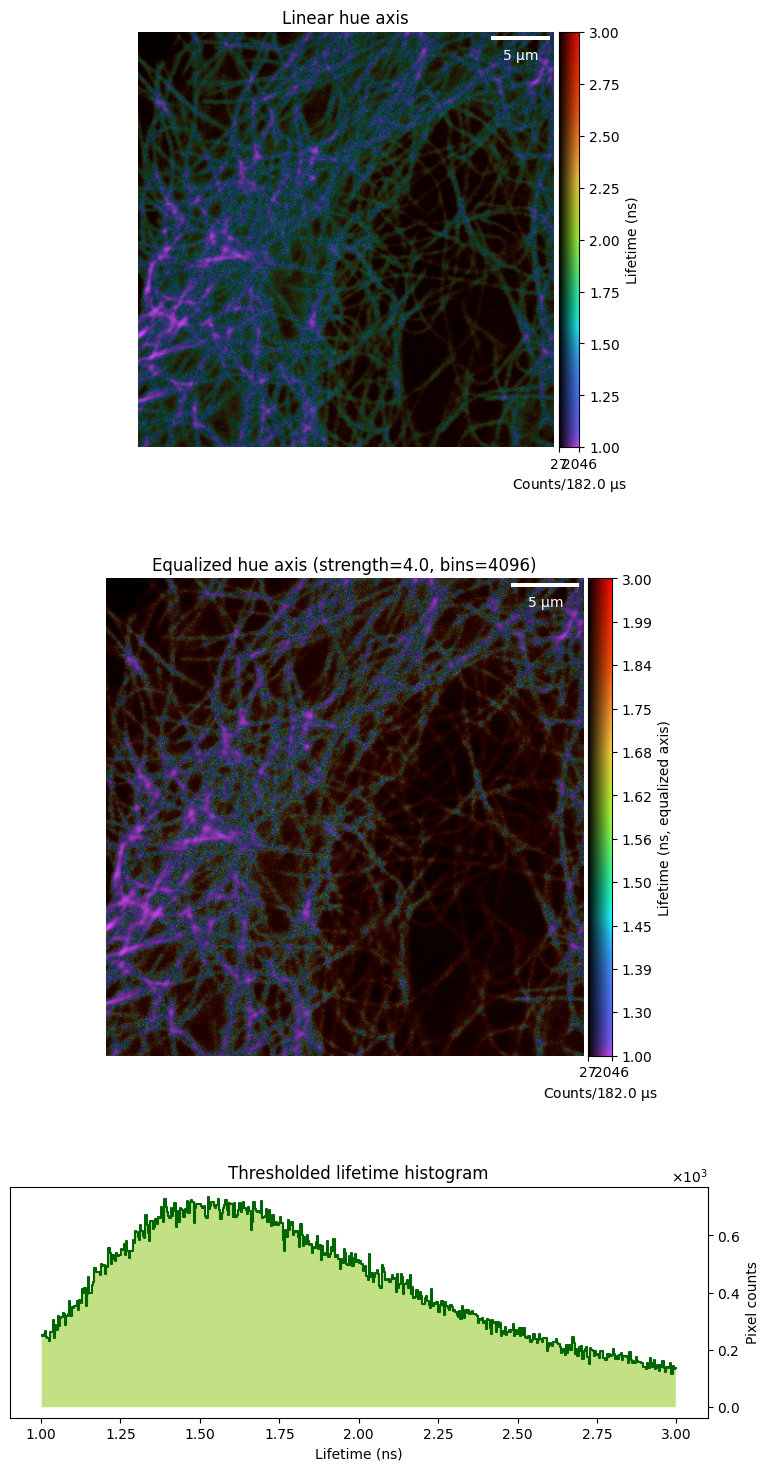

In [16]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 3.0],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau_map,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)



## Optional Export

`FILENAME_OUTPUT` = enter the path and file name where the phasor plot will be saved (`.h5` format)

Set `FILENAME_OUTPUT` in the export cell below to write a current-schema HDF5 fragment. The output is stored under `/output/phasor/products/` and includes root schema attributes (`data_format_version = "0.0.6"`, `contains_output = True`).


In [ ]:
if FILENAME_OUTPUT is not None:
    phasor_source_path = PIPELINE_H5 if "PIPELINE_H5" in globals() else FILENAME_OUTPUT
    phasor_mode = "append"
    phasor_output_path = None
    apr_output_data_path = APR_OUTPUT_DATA_PATH if DO_APR and "APR_OUTPUT_DATA_PATH" in globals() else ""
    apr_output_run_id = APR_OUTPUT_RUN_ID if DO_APR and "APR_OUTPUT_RUN_ID" in globals() else ""
    phasor_source_data_path = apr_output_data_path or f"/raw/{CALIBRATION_PRODUCT}"
    common_attrs = {
        "source_data_path": phasor_source_data_path,
        "source_calibration_path": f"/calibration/results/{CALIBRATION_PRODUCT}",
        "source_metadata_path": "/raw/metadata",
        "source_axes_path": "/raw/axes",
        "time_axis_source": "/raw/axes/digital_time_ns",
        "time_bin_ns": laser_period_ns / nbin,
        "laser_frequency_mhz": laser_freq_mhz if "laser_freq_mhz" in globals() else laser_frequency_mhz,
        "laser_period_ns": laser_period_ns,
    }
    products = [
        H5OutputProduct("intensity", intensity_map, attrs={**common_attrs, "data_role": "integrated_intensity", "axis_order": "y,x"}),
        H5OutputProduct("phasor_real", np.real(phasor_map), attrs={**common_attrs, "data_role": "phasor_real", "axis_order": "y,x"}),
        H5OutputProduct("phasor_imag", np.imag(phasor_map), attrs={**common_attrs, "data_role": "phasor_imag", "axis_order": "y,x"}),
        H5OutputProduct("tau_m_ns", tau_m_map, attrs={**common_attrs, "data_role": "tau_m", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("tau_phi_ns", tau_phi_map, attrs={**common_attrs, "data_role": "tau_phi", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("tau_ns", lifetime_map, attrs={**common_attrs, "data_role": "primary_lifetime", "units": "ns", "axis_order": "y,x"}),
        H5OutputProduct("decay_sum", data_summed, attrs={**common_attrs, "data_role": "channel_summed_decay", "axis_order": "y,x,time_bin"}),
        H5OutputProduct("irf", irf_summed, attrs={**common_attrs, "data_role": "channel_summed_irf", "axis_order": "time_bin"}),
        H5OutputProduct("ref", ref_summed, attrs={**common_attrs, "data_role": "channel_summed_reference", "axis_order": "time_bin"}),
        H5OutputProduct("irf_phasor_real", np.asarray(np.real(irf_phasor)), attrs={**common_attrs, "data_role": "irf_phasor_real"}),
        H5OutputProduct("irf_phasor_imag", np.asarray(np.imag(irf_phasor)), attrs={**common_attrs, "data_role": "irf_phasor_imag"}),
        H5OutputProduct("ref_phasor_real", np.asarray(np.real(ref_phasor)), attrs={**common_attrs, "data_role": "ref_phasor_real"}),
        H5OutputProduct("ref_phasor_imag", np.asarray(np.imag(ref_phasor)), attrs={**common_attrs, "data_role": "ref_phasor_imag"}),
        H5OutputProduct("corr_real", np.asarray(np.real(correction)), attrs={**common_attrs, "data_role": "phasor_correction_real"}),
        H5OutputProduct("corr_imag", np.asarray(np.imag(correction)), attrs={**common_attrs, "data_role": "phasor_correction_imag"}),
    ]
    target_path, output_run_id = write_h5_output_run(
        phasor_source_path,
        "phasor",
        products,
        mode=phasor_mode,
        output_path=phasor_output_path,
        output_key_overwrite=True,
        output_type="image_tool",
        tool_name="Phasor lifetime",
        algorithm_name="phasor_correction",
        parameters={
            "reference_type": REFERENCE_TYPE,
            "tau_ref_input_ns": TAU_REF,
            "tau_ref_used_ns": tau_ref_for_phasor_ns,
            "threshold_fraction": threshold,
            "data_key": DATA_KEY,
            "calibration_product": CALIBRATION_PRODUCT,
            "apr_output_run_id": apr_output_run_id,
            "apr_output_data_path": apr_output_data_path,
        },
        metadata={
            **common_attrs,
            "pixel_size_x_um": pixel_size_x_um,
            "pixel_dwell_time_us": pxdwelltime,
            "output_ny": intensity_map.shape[0],
            "output_nx": intensity_map.shape[1],
            "output_time_bins": data_summed.shape[-1],
            "selected_channel_count": data_input.shape[-1],
            "channel_aggregation": "sum_channels_with_skew_correction",
            "apr_output_run_id": apr_output_run_id,
            "apr_output_data_path": apr_output_data_path,
        },
        axes=[
                H5OutputProduct("repetition_index", np.asarray([0.0]) if data_input.shape[0] == 1 else np.arange(data_input.shape[0], dtype=float), attrs={"axis": "repetition", "long_name": "repetition index", "units": "index"}),
                H5OutputProduct("time_ns", t, attrs={"axis": "time_bin", "long_name": "time", "units": "ns"}),
                H5OutputProduct("x_um", np.linspace(-pixel_size_x_um * (data_input.shape[3] - 1) / 2, pixel_size_x_um * (data_input.shape[3] - 1) / 2, data_input.shape[3]) if data_input.shape[3] > 1 else np.asarray([0.0]), attrs={"axis": "x", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "x position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((data_input.shape[3] - 1) * pixel_size_x_um) if data_input.shape[3] > 1 else 0.0, "units": "um"}),
                H5OutputProduct("y_um", np.linspace(-pixel_size_x_um * (data_input.shape[2] - 1) / 2, pixel_size_x_um * (data_input.shape[2] - 1) / 2, data_input.shape[2]) if data_input.shape[2] > 1 else np.asarray([0.0]), attrs={"axis": "y", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "y position", "offset_um": 0.0, "pixel_size_um": pixel_size_x_um, "range_um": float((data_input.shape[2] - 1) * pixel_size_x_um) if data_input.shape[2] > 1 else 0.0, "units": "um"}),
                H5OutputProduct("z_um", np.asarray([0.0]) if data_input.shape[1] == 1 else np.arange(data_input.shape[1], dtype=float), attrs={"axis": "z", "coordinate_rule": "linspace(offset_um - range_um/2, offset_um + range_um/2, n)", "long_name": "z position", "offset_um": 0.0, "pixel_size_um": 0.0, "range_um": 0.0, "units": "um"}),
            ],
        attrs={
            **common_attrs,
            "input_axis_order": "repetition,z,y,x,time_bin,detector_channel",
            "output_axis_order": "y,x",
            "output_data_path": "/output/{run_id}/products/tau_ns",
        },
        set_default=True,
    )
    PIPELINE_H5 = target_path
    print(f"Saved {output_run_id} -> {target_path}")
else:
    print("Export skipped (FILENAME_OUTPUT = None).")


Saved phasor -> /mnt/DATA/Mixed Data/Giuse2/Test_01_small_DFD_phasor_workflow.h5


In [19]:
_ = show_h5_structure_html(FILENAME_OUTPUT)